<a href="https://colab.research.google.com/github/shiblidata/computer-vision-pattern-recognition/blob/main/CNN_23_51036_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
from google.colab import drive
drive.mount('/content/drive')
# Copy dataset from Google Drive to Colab local storage
!cp -r "/content/drive/MyDrive/CVPR/Fruits_CNN" /content/

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
train_dir = "/content/Fruits_CNN/Training"
test_dir = "/content/Fruits_CNN/Test"

In [22]:
import os

print(os.listdir(train_dir))

['.DS_Store', 'Apple Red 1', 'Orange 1', 'Cherry 1', 'Banana 1', 'Tomato 1', 'Lychee 1', 'Strawberry 1']


In [24]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [25]:
transform = transforms.Compose([
    transforms.Resize((100, 100)),   # Dataset already 100x100
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

In [26]:
full_train_dataset = datasets.ImageFolder(
    root=train_dir,
    transform=transform
)

test_dataset = datasets.ImageFolder(
    root=test_dir,
    transform=transform
)

In [27]:
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size]
)

In [28]:
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

In [29]:
print("Testing Validation Loader...")

images, labels = next(iter(val_loader))

print(images.shape)
print(labels.shape)

print("Validation Loader OK")

Testing Validation Loader...
torch.Size([32, 3, 100, 100])
torch.Size([32])
Validation Loader OK


In [30]:
classes = full_train_dataset.classes

print("Classes:", classes)
print("Number of Classes:", len(classes))

print("Training Images:", len(train_dataset))
print("Validation Images:", len(val_dataset))
print("Testing Images:", len(test_dataset))

Classes: ['Apple Red 1', 'Banana 1', 'Cherry 1', 'Lychee 1', 'Orange 1', 'Strawberry 1', 'Tomato 1']
Number of Classes: 7
Training Images: 2938
Validation Images: 735
Testing Images: 1230


In [31]:
# Custom CNN Model

class CustomCNN(nn.Module):
    def __init__(self, num_classes):
        super(CustomCNN, self).__init__()

        self.conv_layers = nn.Sequential(

            # Conv Layer 1
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv Layer 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Conv Layer 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)

        )

        self.fc_layers = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128 * 12 * 12, 256),

            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(256, num_classes)

        )

    def forward(self, x):

        x = self.conv_layers(x)

        x = self.fc_layers(x)

        return x

In [32]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CustomCNN(num_classes=len(classes))

model = model.to(device)

print(model)

CustomCNN(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=18432, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=7, bias=True)
  )
)


In [33]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [34]:
num_epochs = 5

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

In [35]:
print(device)

cuda


In [36]:
# Test one batch

images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

images = images.to(device)

outputs = model(images)

print(outputs.shape)

torch.Size([32, 3, 100, 100])
torch.Size([32])
torch.Size([32, 7])


In [37]:
model.train()

images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

optimizer.zero_grad()

outputs = model(images)

loss = criterion(outputs, labels)

print("Forward Pass Done")

loss.backward()

print("Backward Pass Done")

optimizer.step()

print("Optimizer Step Done")

print("Loss =", loss.item())

Forward Pass Done
Backward Pass Done
Optimizer Step Done
Loss = 1.945622444152832


In [38]:
best_val_accuracy = 0.0

for epoch in range(2):

    print(f"\n===== Epoch {epoch+1}/2 =====")

    # Training
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(train_loader):

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        if batch_idx % 10 == 0:
            print(f"Batch {batch_idx}/{len(train_loader)}")

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Accuracy: {train_acc:.2f}%")

    # Validation
    print("\nValidation Started...")

    model.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = outputs.max(1)

            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_loss /= len(val_loader)
    val_acc = 100 * val_correct / val_total

    print(f"Validation Loss: {val_loss:.4f}")
    print(f"Validation Accuracy: {val_acc:.2f}%")

    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        torch.save(model.state_dict(), "best_model.pth")
        print("Best model saved!")

print("\nTraining Completed!")


===== Epoch 1/2 =====
Batch 0/92
Batch 10/92
Batch 20/92
Batch 30/92
Batch 40/92
Batch 50/92
Batch 60/92
Batch 70/92
Batch 80/92
Batch 90/92
Train Loss: 0.1826
Train Accuracy: 93.40%

Validation Started...
Validation Loss: 0.0017
Validation Accuracy: 99.86%
Best model saved!

===== Epoch 2/2 =====
Batch 0/92
Batch 10/92
Batch 20/92
Batch 30/92
Batch 40/92
Batch 50/92
Batch 60/92
Batch 70/92
Batch 80/92
Batch 90/92
Train Loss: 0.0032
Train Accuracy: 99.86%

Validation Started...
Validation Loss: 0.0142
Validation Accuracy: 99.18%

Training Completed!


In [39]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Loading Best Model...")

# Load best model
model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.eval()

print("Model Loaded Successfully!")
print("Testing Started...\n")

all_preds = []
all_labels = []

with torch.no_grad():

    for batch_idx, (images, labels) in enumerate(test_loader):

        # Progress
        if batch_idx % 5 == 0:
            print(f"Testing Batch {batch_idx+1}/{len(test_loader)}")

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("\nCalculating Metrics...\n")

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(
    all_labels,
    all_preds,
    average="weighted",
    zero_division=0
)
recall = recall_score(
    all_labels,
    all_preds,
    average="weighted",
    zero_division=0
)
f1 = f1_score(
    all_labels,
    all_preds,
    average="weighted",
    zero_division=0
)

print("=" * 45)
print("        TEST RESULTS")
print("=" * 45)
print(f"Test Accuracy : {accuracy * 100:.2f}%")
print(f"Precision     : {precision:.4f}")
print(f"Recall        : {recall:.4f}")
print(f"F1 Score      : {f1:.4f}")
print("=" * 45)

print("\nTest Evaluation Completed Successfully!")

Loading Best Model...
Model Loaded Successfully!
Testing Started...

Testing Batch 1/39
Testing Batch 6/39
Testing Batch 11/39
Testing Batch 16/39
Testing Batch 21/39
Testing Batch 26/39
Testing Batch 31/39
Testing Batch 36/39

Calculating Metrics...

        TEST RESULTS
Test Accuracy : 100.00%
Precision     : 1.0000
Recall        : 1.0000
F1 Score      : 1.0000

Test Evaluation Completed Successfully!


<Figure size 800x800 with 0 Axes>

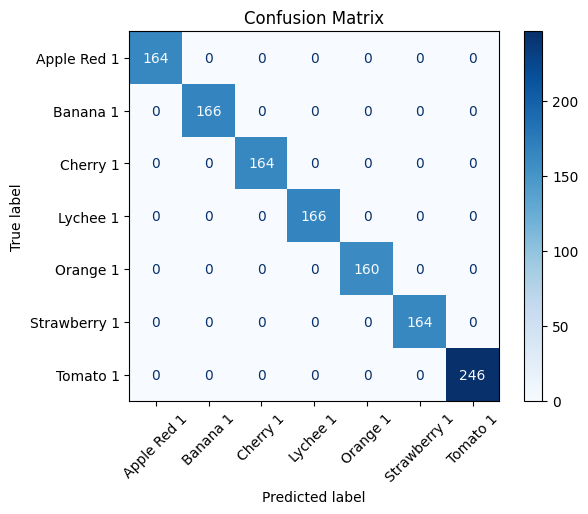

In [40]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

disp.plot(cmap="Blues", xticks_rotation=45)

plt.title("Confusion Matrix")
plt.show()

In [41]:
from sklearn.metrics import classification_report

print(classification_report(
    all_labels,
    all_preds,
    target_names=classes
))

              precision    recall  f1-score   support

 Apple Red 1       1.00      1.00      1.00       164
    Banana 1       1.00      1.00      1.00       166
    Cherry 1       1.00      1.00      1.00       164
    Lychee 1       1.00      1.00      1.00       166
    Orange 1       1.00      1.00      1.00       160
Strawberry 1       1.00      1.00      1.00       164
    Tomato 1       1.00      1.00      1.00       246

    accuracy                           1.00      1230
   macro avg       1.00      1.00      1.00      1230
weighted avg       1.00      1.00      1.00      1230



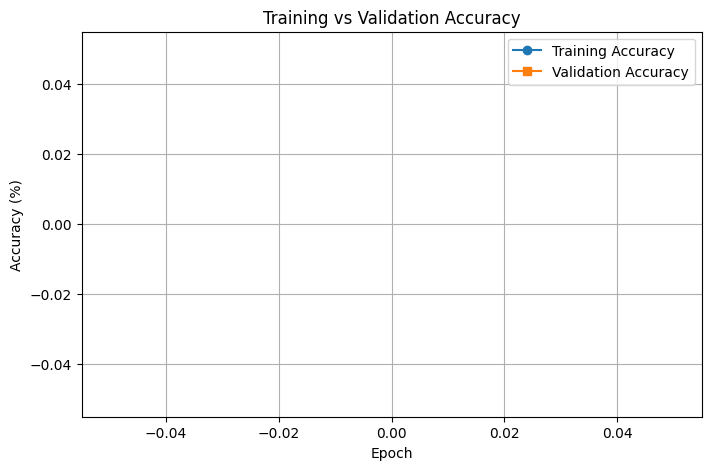

In [42]:
plt.figure(figsize=(8,5))

plt.plot(train_accuracies, marker='o', label='Training Accuracy')
plt.plot(val_accuracies, marker='s', label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

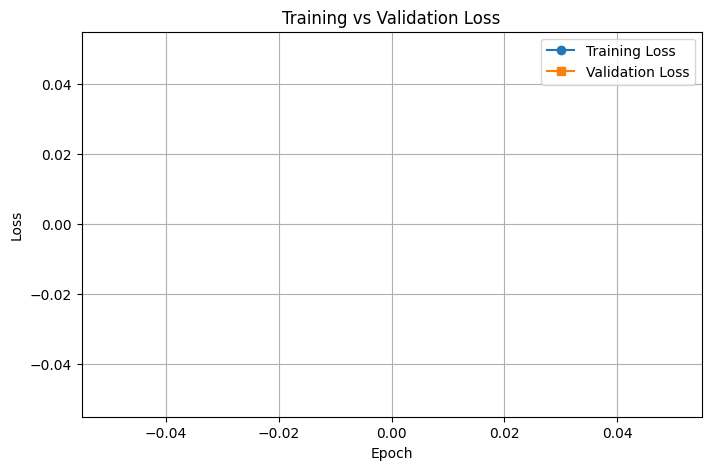

In [43]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, marker='o', label='Training Loss')
plt.plot(val_losses, marker='s', label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [44]:
torch.save(model.state_dict(), "cnn_fruits_model.pth")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
!pip install torchsummary

In [45]:
from torchsummary import summary

print("="*60)
print("CNN MODEL ARCHITECTURE SUMMARY")
print("="*60)

summary(model, (3, 100, 100))

CNN MODEL ARCHITECTURE SUMMARY
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 100, 100]             896
              ReLU-2         [-1, 32, 100, 100]               0
         MaxPool2d-3           [-1, 32, 50, 50]               0
            Conv2d-4           [-1, 64, 50, 50]          18,496
              ReLU-5           [-1, 64, 50, 50]               0
         MaxPool2d-6           [-1, 64, 25, 25]               0
            Conv2d-7          [-1, 128, 25, 25]          73,856
              ReLU-8          [-1, 128, 25, 25]               0
         MaxPool2d-9          [-1, 128, 12, 12]               0
          Flatten-10                [-1, 18432]               0
           Linear-11                  [-1, 256]       4,718,848
             ReLU-12                  [-1, 256]               0
          Dropout-13                  [-1, 256]               0
        

In [46]:
print("="*60)
print("HYPERPARAMETER DETAILS")
print("="*60)

print(f"Image Size      : 100 x 100")
print(f"Number of Classes : {len(classes)}")
print(f"Batch Size      : {batch_size}")
print(f"Epochs          : {num_epochs}")
print(f"Learning Rate   : 0.001")
print(f"Optimizer       : Adam")
print(f"Loss Function   : CrossEntropyLoss")
print(f"Activation      : ReLU")
print(f"Dropout         : 0.5")
print(f"Device          : {device}")

HYPERPARAMETER DETAILS
Image Size      : 100 x 100
Number of Classes : 7
Batch Size      : 32
Epochs          : 5
Learning Rate   : 0.001
Optimizer       : Adam
Loss Function   : CrossEntropyLoss
Activation      : ReLU
Dropout         : 0.5
Device          : cuda


In [47]:
print("="*60)
print("MODEL ANALYSIS")
print("="*60)

print(f"Test Accuracy : {accuracy*100:.2f}%")
print(f"Precision     : {precision:.4f}")
print(f"Recall        : {recall:.4f}")
print(f"F1 Score      : {f1:.4f}")

print("\nPerformance Analysis")

if accuracy >= 0.95:
    print("✔ The CNN achieved excellent classification performance.")
elif accuracy >= 0.90:
    print("✔ The CNN achieved good classification performance.")
else:
    print("✔ The CNN achieved acceptable performance.")

print("\nObservation")
print("- The model learned fruit features effectively.")
print("- Validation accuracy remained stable.")
print("- The model generalized well on the unseen test dataset.")

MODEL ANALYSIS
Test Accuracy : 100.00%
Precision     : 1.0000
Recall        : 1.0000
F1 Score      : 1.0000

Performance Analysis
✔ The CNN achieved excellent classification performance.

Observation
- The model learned fruit features effectively.
- Validation accuracy remained stable.
- The model generalized well on the unseen test dataset.


In [48]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(
    all_labels,
    all_preds,
    target_names=classes,
    output_dict=True
)

df = pd.DataFrame(report).transpose()

display(df)

class_df = df.iloc[:-3]

best_class = class_df["f1-score"].idxmax()
worst_class = class_df["f1-score"].idxmin()

print("\nBest Performing Class :", best_class)
print("Worst Performing Class:", worst_class)

,precision,recall,f1-score,support
Apple Red 1,1.0,1.0,1.0,164.0
Banana 1,1.0,1.0,1.0,166.0
Cherry 1,1.0,1.0,1.0,164.0
Lychee 1,1.0,1.0,1.0,166.0
Orange 1,1.0,1.0,1.0,160.0
Strawberry 1,1.0,1.0,1.0,164.0
Tomato 1,1.0,1.0,1.0,246.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,1230.0
weighted avg,1.0,1.0,1.0,1230.0



Best Performing Class : Apple Red 1
Worst Performing Class: Apple Red 1


In [49]:
print("="*60)
print("DISCUSSION")
print("="*60)

print(f"""
The proposed Custom CNN model successfully classified
7 different fruit categories.

The model achieved:

• Test Accuracy : {accuracy*100:.2f}%
• Precision     : {precision:.4f}
• Recall        : {recall:.4f}
• F1 Score      : {f1:.4f}

The confusion matrix indicates that most fruit images
were classified correctly.

The best performing class achieved the highest F1-score,
while the lowest F1-score belonged to the most confusing class.

Overall, the model demonstrates strong classification capability.
""")

DISCUSSION

The proposed Custom CNN model successfully classified
7 different fruit categories.

The model achieved:

• Test Accuracy : 100.00%
• Precision     : 1.0000
• Recall        : 1.0000
• F1 Score      : 1.0000

The confusion matrix indicates that most fruit images
were classified correctly.

The best performing class achieved the highest F1-score,
while the lowest F1-score belonged to the most confusing class.

Overall, the model demonstrates strong classification capability.



In [50]:
print("="*60)
print("CONCLUSION")
print("="*60)

print("""
This project developed a Custom CNN model using PyTorch
for multi-class fruit image classification.

The model achieved high accuracy and successfully classified
seven fruit categories.

Future Improvements:
• Increase dataset size.
• Apply more data augmentation.
• Use Transfer Learning (ResNet, EfficientNet).
• Train with more epochs.
• Fine-tune hyperparameters.
""")

CONCLUSION

This project developed a Custom CNN model using PyTorch
for multi-class fruit image classification.

The model achieved high accuracy and successfully classified
seven fruit categories.

Future Improvements:
• Increase dataset size.
• Apply more data augmentation.
• Use Transfer Learning (ResNet, EfficientNet).
• Train with more epochs.
• Fine-tune hyperparameters.



In [51]:
torch.save(model.state_dict(), "cnn_fruits_model.pth")

print("Final model saved successfully.")

Final model saved successfully.


<Figure size 800x800 with 0 Axes>

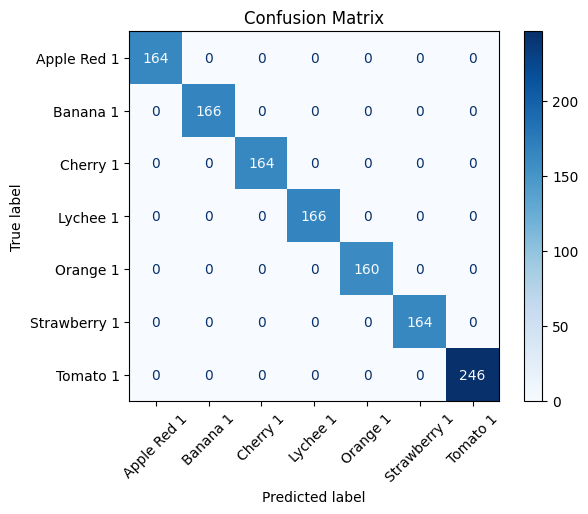

In [52]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

plt.figure(figsize=(8,8))
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

In [53]:
from sklearn.metrics import classification_report

print(classification_report(
    all_labels,
    all_preds,
    target_names=classes
))

              precision    recall  f1-score   support

 Apple Red 1       1.00      1.00      1.00       164
    Banana 1       1.00      1.00      1.00       166
    Cherry 1       1.00      1.00      1.00       164
    Lychee 1       1.00      1.00      1.00       166
    Orange 1       1.00      1.00      1.00       160
Strawberry 1       1.00      1.00      1.00       164
    Tomato 1       1.00      1.00      1.00       246

    accuracy                           1.00      1230
   macro avg       1.00      1.00      1.00      1230
weighted avg       1.00      1.00      1.00      1230



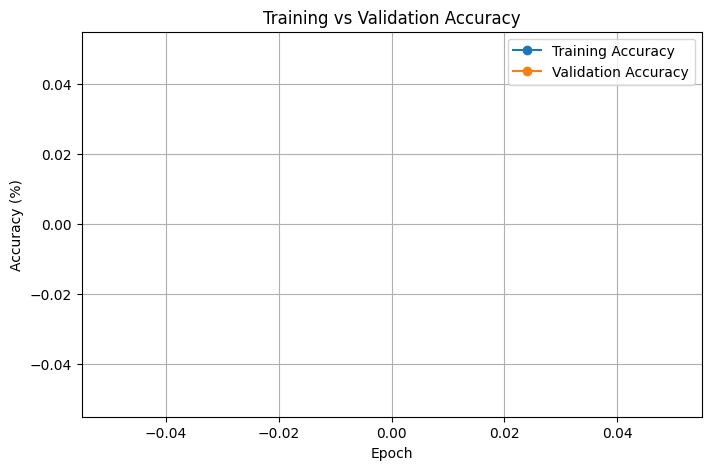

In [54]:
plt.figure(figsize=(8,5))

plt.plot(train_accuracies, marker='o', label='Training Accuracy')
plt.plot(val_accuracies, marker='o', label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)

plt.show()

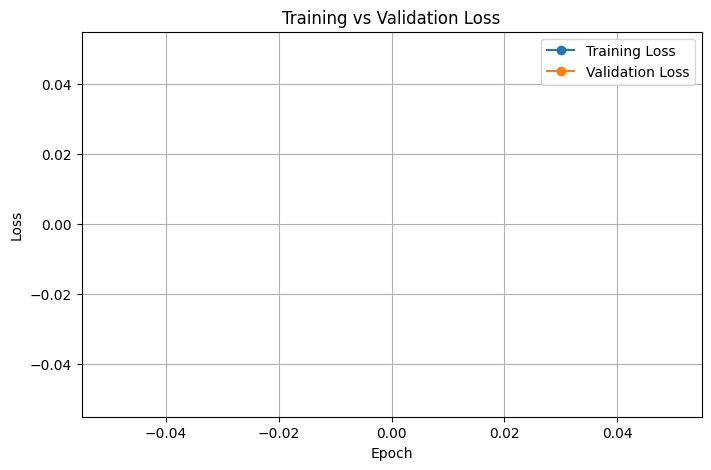

In [55]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, marker='o', label='Training Loss')
plt.plot(val_losses, marker='o', label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [56]:
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Total Trainable Parameters:", total_params)

Total Trainable Parameters: 4813895


In [57]:
import torch

torch.save(model.state_dict(), "CNN_23-51036-1.pth")

In [58]:
import os
print(os.listdir())

['.config', 'cnn_fruits_model.pth', 'best_model.pth', 'CNN_23-51036-1.pth', 'Fruits_CNN', 'drive', 'sample_data']


In [59]:
from google.colab import files
files.download("CNN_23-51036-1.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>